In [1]:
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [2]:
%matplotlib inline

In [3]:
data = sio.loadmat('data/data.mat', squeeze_me=True, struct_as_record=False)['data']
print(len(data))

80788


In [4]:
type(data)

numpy.ndarray

In [5]:
type(data[0])

scipy.io.matlab._mio5_params.mat_struct

In [6]:
type(data[0].boundary)

numpy.ndarray

In [7]:
data[2].name

'10'

In [8]:
name_to_index = { floorPlan.name : i for i, floorPlan in enumerate(data) }

# Draw floor plan

In [9]:
def draw_boundary(floorPlan):
    # Plotting a boundary

    start = 2
    end = floorPlan.boundary.shape[0]

    x = floorPlan.boundary[start:end, 0]
    y = floorPlan.boundary[start:end, 1]

    if floorPlan.boundary[0, 3] == 0:
        x = np.append(x, floorPlan.boundary[0, 0])
        y = np.append(y, floorPlan.boundary[0, 1])

    if floorPlan.boundary[1, 3] == 0:
        x = np.append(x, floorPlan.boundary[1, 0])
        y = np.append(y, floorPlan.boundary[1, 1])
    

    x = np.append(x, floorPlan.boundary[2, 0])
    y = np.append(y, floorPlan.boundary[2, 1])

    plt.plot(x, y)

    # Plotting doors

    end = 2
    start = 0

    x = floorPlan.boundary[start:end, 0]
    y = floorPlan.boundary[start:end, 1]


    plt.plot(x, y, marker = 'o')

    plt.axis('equal')
    plt.grid()
    plt.gca().invert_yaxis()

    plt.title(f'Floor plan {floorPlan.name}')

    plt.show()

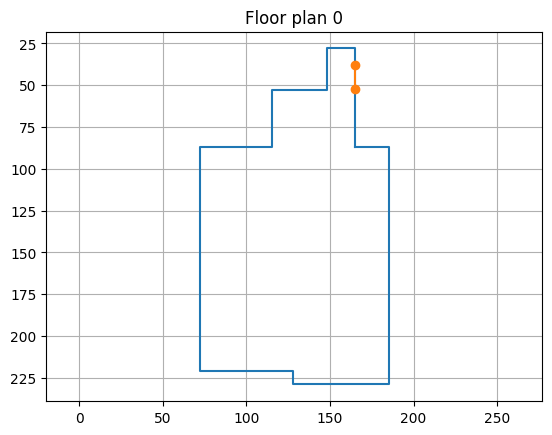

In [10]:
draw_boundary(data[name_to_index['0']])

In [11]:
room_label = [
    (0, 'LivingRoom', 1, "PublicArea"),
    (1, 'MasterRoom', 0, "Bedroom"),
    (2, 'Kitchen', 1, "FunctionArea"),
    (3, 'Bathroom', 0, "FunctionArea"),
    (4, 'DiningRoom', 1, "FunctionArea"),
    (5, 'ChildRoom', 0, "Bedroom"),
    (6, 'StudyRoom', 0, "Bedroom"),
    (7, 'SecondRoom', 0, "Bedroom"),
    (8, 'GuestRoom', 0, "Bedroom"),
    (9, 'Balcony', 1, "PublicArea"),
    (10, 'Entrance', 1, "PublicArea"),
    (11, 'Storage', 0, "PublicArea"),
    (12, 'Wall-in', 0, "PublicArea"),
]

In [12]:
def draw_room_boundary(floorPlan):

    for room in floorPlan.rBoundary:
        x = room[:, 0]
        y = room[:, 1]

        x = np.append(x, room[0, 0])
        y = np.append(y, room[0, 1])

        plt.plot(x, y)

    plt.grid()
    plt.ylim(0, 250)
    plt.xlim(0, 250)
    plt.gca().invert_yaxis()

    plt.title(f'Floor plan {floorPlan.name}')

    plt.show()

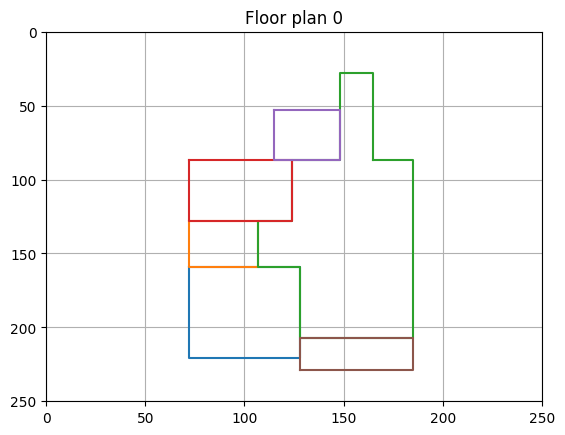

In [13]:
draw_room_boundary(data[0])

In [14]:
def draw_rooms(floorPlan):
    roomsNb = len(floorPlan.rType)

    fig, axes = plt.subplots(3, roomsNb, figsize=(roomsNb*3, 3*4))

    for i, boundary in enumerate(floorPlan.rBoundary):
        # Drawing room boundary
        x = boundary[:, 0]
        y = boundary[:, 1]

        x = np.append(x, boundary[0, 0])
        y = np.append(y, boundary[0, 1])

        axes[0, i].plot(x, y)

        axes[0, i].grid()
        axes[0, i].set_ylim(250, 0)
        axes[0, i].set_xlim(0, 250)

        room_name = room_label[floorPlan.rType[i]][1]
        axes[0, i].set_title(f'{room_name} boundary')

    for i, box in enumerate(floorPlan.gtBox[:-1]):
        # Draw bbox
        width = box[3] - box[1]
        height = box[2]-box[0]

        rect = patches.Rectangle((box[1], box[0]), width, height)

        axes[1, i].add_patch(rect)
        axes[1, i].grid()
        axes[1, i].set_ylim(250, 0)
        axes[1, i].set_xlim(0, 250)

        room_name = room_label[floorPlan.rType[i]][1]
        axes[1, i].set_title(f'{room_name} box - RPLAN')

    for i, box in enumerate(floorPlan.gtBoxNew[:-1]):
        # Draw bbox
        width = box[3] - box[1]
        height = box[2]-box[0]

        rect = patches.Rectangle((box[1], box[0]), width, height)

        axes[2, i].add_patch(rect)
        axes[2, i].grid()
        axes[2, i].set_ylim(250, 0)
        axes[2, i].set_xlim(0, 250)

        room_name = room_label[floorPlan.rType[i]][1]
        axes[2, i].set_title(f'{room_name} box new - Graph2Plan')

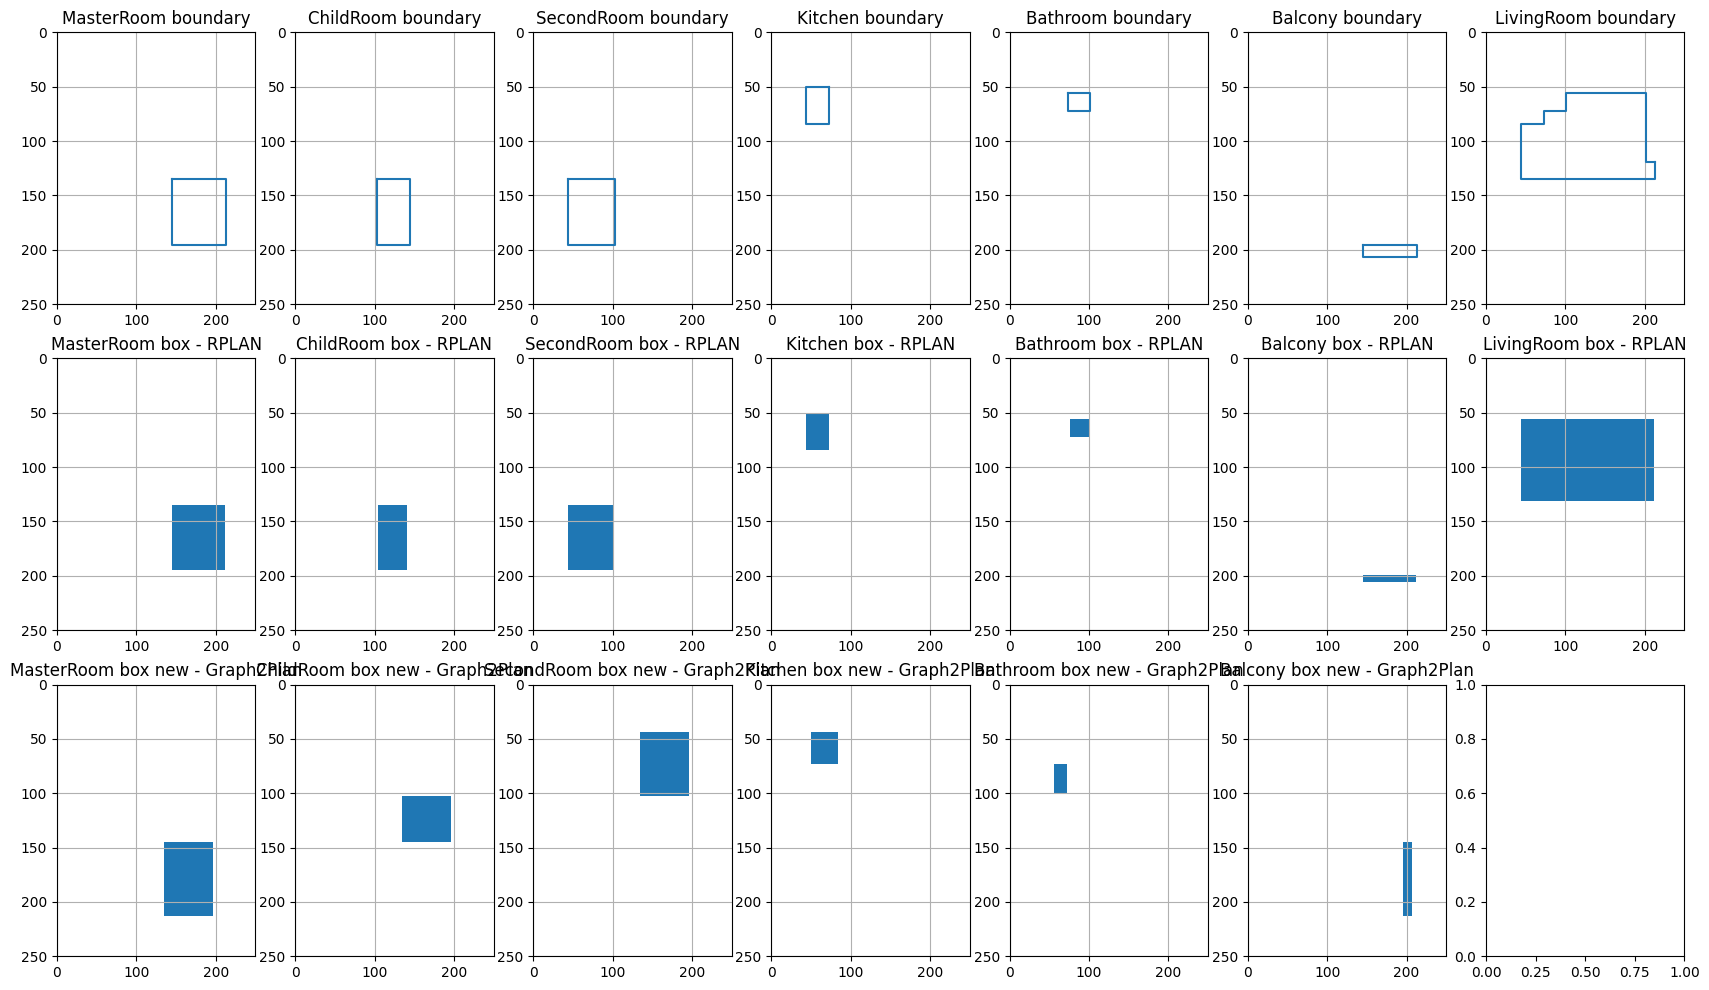

In [15]:
draw_rooms(data[1])

In [16]:
len(data[0].gtBox)

7

In [17]:
planIndex = 0
roomIndex = 5

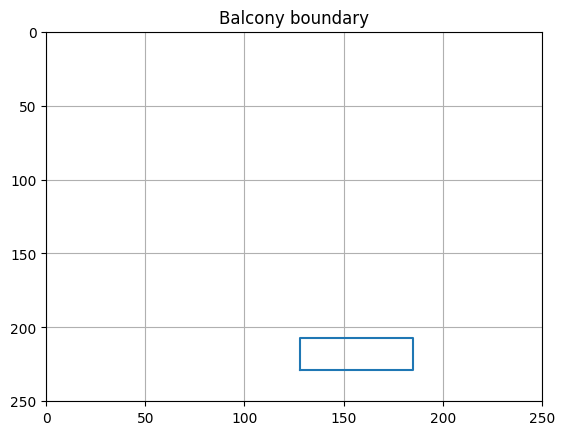

In [18]:
room = data[planIndex].rBoundary[roomIndex]

x = room[:, 0]
y = room[:, 1]

x = np.append(x, room[0, 0])
y = np.append(y, room[0, 1])

plt.plot(x, y)

plt.grid()
plt.ylim(0, 250)
plt.xlim(0, 250)
plt.gca().invert_yaxis()

plt.title(f'{room_label[data[planIndex].rType[roomIndex]][1]} boundary')

plt.show()

Text(0.5, 1.0, 'Balcony box')

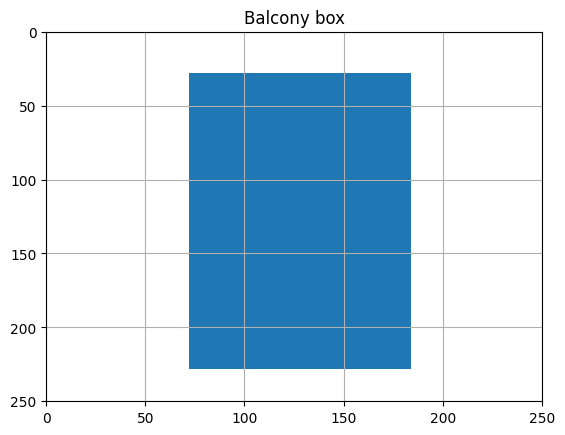

In [19]:
room = data[planIndex].gtBox[6]

rect = patches.Rectangle((room[1], room[0]), room[3] - room[1], room[2]-room[0])

fig, ax = plt.subplots()

ax.add_patch(rect)

plt.grid()
plt.ylim(0, 250)
plt.xlim(0, 250)
plt.gca().invert_yaxis()

plt.title(f'{room_label[data[planIndex].rType[roomIndex]][1]} box')

In [20]:
data[0].gtBox

array([[161,  72, 220, 124],
       [130,  72, 157, 107],
       [ 28, 111, 203, 184],
       [ 87,  72, 126, 124],
       [ 53, 115,  83, 144],
       [207, 128, 228, 184],
       [ 28,  72, 228, 184]], dtype=int32)

# Number of room types

In [21]:
rooms_cnt = np.zeros(len(room_label), dtype=np.int32)
rooms_cnt.shape

(13,)

In [22]:
for floorPlan in data:
    for room in floorPlan.rType:
        rooms_cnt[room] += 1

In [23]:
room_names = []

for room_desc in  room_label:
    room_names.append(room_desc[1])

len(room_names)

13

<BarContainer object of 13 artists>

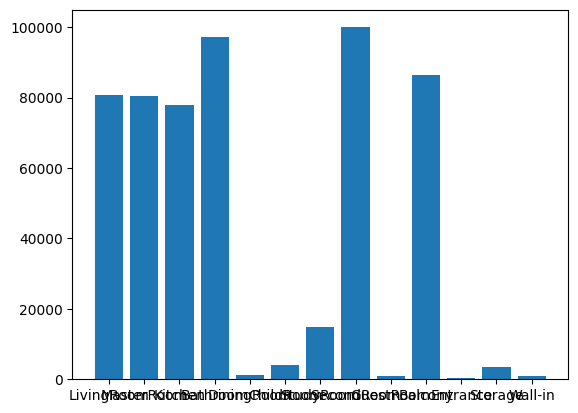

In [24]:
plt.bar(room_names, rooms_cnt)

In [25]:
rooms_cnt

array([80788, 80466, 77768, 97113,  1312,  3928, 14985, 99987,   860,
       86545,   292,  3351,  1043], dtype=int32)

# Max corners count

In [29]:
from src.mat_file import from_mat_file
from src.dataset_loader import load_dataset_from_mat_file

/home/pnieck/Repos/FloorPlanGen/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [30]:
data = load_dataset_from_mat_file("data/data.mat")
floor_plans = []

for plan in data:
    floor_plans.append(from_mat_file(plan))

In [31]:
max_corners = 0

for plan in floor_plans:
    if max_corners < plan.boundary_len:
        max_corners = plan.boundary_len

    for room in plan.rooms:
        if max_corners < room.boundary_len:
            max_corners = room.boundary_len

max_corners

58